In [1]:
setwd("~/Projects/R/ISLR2")

In [2]:
source("InstallAndLoadScripts/loadlibraries.R")

In [3]:
loadISLR2Libraries()

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.2.0     ✔ readr     2.2.0
✔ forcats   1.0.1     ✔ stringr   1.6.0
✔ ggplot2   4.0.2     ✔ tibble    3.3.1
✔ lubridate 1.9.5     ✔ tidyr     1.3.2
✔ purrr     1.2.1     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
✖ dplyr::select() masks MASS::select()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors

Attaching package: ‘ISLR2’


The following object is masked from ‘package:MASS’:

    Boston


Loading required package: ggpp

Registered S3 methods overwritten by 'ggpp':
  method                  from   
  heightDetails.titleGrob ggplot2
  widthDetails.titleGrob  ggplot2


Attaching package: ‘ggpp’


The following object is masked from ‘package:ggplot2’:

    annotate



Attaching package: ‘gridExtra’


The following object is mas

In [4]:
as_tibble(Hitters)[1:10,]

AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<fct>,<fct>,<int>,<int>,<int>,<dbl>,<fct>
293,66,1,30,29,14,1,293,66,1,30,29,14,A,E,446,33,20,NA,A
315,81,7,24,38,39,14,3449,835,69,321,414,375,N,W,632,43,10,475.0,N
479,130,18,66,72,76,3,1624,457,63,224,266,263,A,W,880,82,14,480.0,A
496,141,20,65,78,37,11,5628,1575,225,828,838,354,N,E,200,11,3,500.0,N
321,87,10,39,42,30,2,396,101,12,48,46,33,N,E,805,40,4,91.5,N
594,169,4,74,51,35,11,4408,1133,19,501,336,194,A,W,282,421,25,750.0,A
185,37,1,23,8,21,2,214,42,1,30,9,24,N,E,76,127,7,70.0,A
298,73,0,24,24,7,3,509,108,0,41,37,12,A,W,121,283,9,100.0,A
323,81,6,26,32,8,2,341,86,6,32,34,8,N,W,143,290,19,75.0,N


In [5]:
?Hitters

Hitters {ISLR2},R Documentation


In [6]:
names(Hitters)

[1] "AtBat"     "Hits"      "HmRun"     "Runs"      "RBI"       "Walks"    
 [7] "Years"     "CAtBat"    "CHits"     "CHmRun"    "CRuns"     "CRBI"     
[13] "CWalks"    "League"    "Division"  "PutOuts"   "Assists"   "Errors"   
[19] "Salary"    "NewLeague"

In [7]:
dim(Hitters)

[1] 322  20

In [8]:
sum(is.na(Hitters))

[1] 59

In [9]:
Hitters = na.omit(Hitters)

In [10]:
dim(Hitters)

[1] 263  20

In [11]:
library(leaps)

In [12]:
regfit.full = regsubsets(Salary ~ ., Hitters)

In [13]:
summary(regfit.full)

Subset selection object
Call: regsubsets.formula(Salary ~ ., Hitters)
19 Variables  (and intercept)
           Forced in Forced out
AtBat          FALSE      FALSE
Hits           FALSE      FALSE
HmRun          FALSE      FALSE
Runs           FALSE      FALSE
RBI            FALSE      FALSE
Walks          FALSE      FALSE
Years          FALSE      FALSE
CAtBat         FALSE      FALSE
CHits          FALSE      FALSE
CHmRun         FALSE      FALSE
CRuns          FALSE      FALSE
CRBI           FALSE      FALSE
CWalks         FALSE      FALSE
LeagueN        FALSE      FALSE
DivisionW      FALSE      FALSE
PutOuts        FALSE      FALSE
Assists        FALSE      FALSE
Errors         FALSE      FALSE
NewLeagueN     FALSE      FALSE
1 subsets of each size up to 8
Selection Algorithm: exhaustive
         AtBat Hits HmRun Runs RBI Walks Years CAtBat CHits CHmRun CRuns CRBI
1  ( 1 ) " "   " "  " "   " "  " " " "   " "   " "    " "   " "    " "   "*" 
2  ( 1 ) " "   "*"  " "   " "  " " " "   

In [14]:
regfit.full = regsubsets(Salary ~ ., Hitters, nvmax=19)

In [15]:
reg.summary = summary(regfit.full)

In [16]:
names(reg.summary)

[1] "which"  "rsq"    "rss"    "adjr2"  "cp"     "bic"    "outmat" "obj"

In [17]:
reg.summary$rsq

[1] 0.3214501 0.4252237 0.4514294 0.4754067 0.4908036 0.5087146 0.5141227
 [8] 0.5285569 0.5346124 0.5404950 0.5426153 0.5436302 0.5444570 0.5452164
[15] 0.5454692 0.5457656 0.5459518 0.5460945 0.5461159

In [18]:
reg.summary$adjr2

[1] 0.3188503 0.4208024 0.4450753 0.4672734 0.4808971 0.4972001 0.5007849
 [8] 0.5137083 0.5180572 0.5222606 0.5225706 0.5217245 0.5206736 0.5195431
[15] 0.5178661 0.5162219 0.5144464 0.5126097 0.5106270

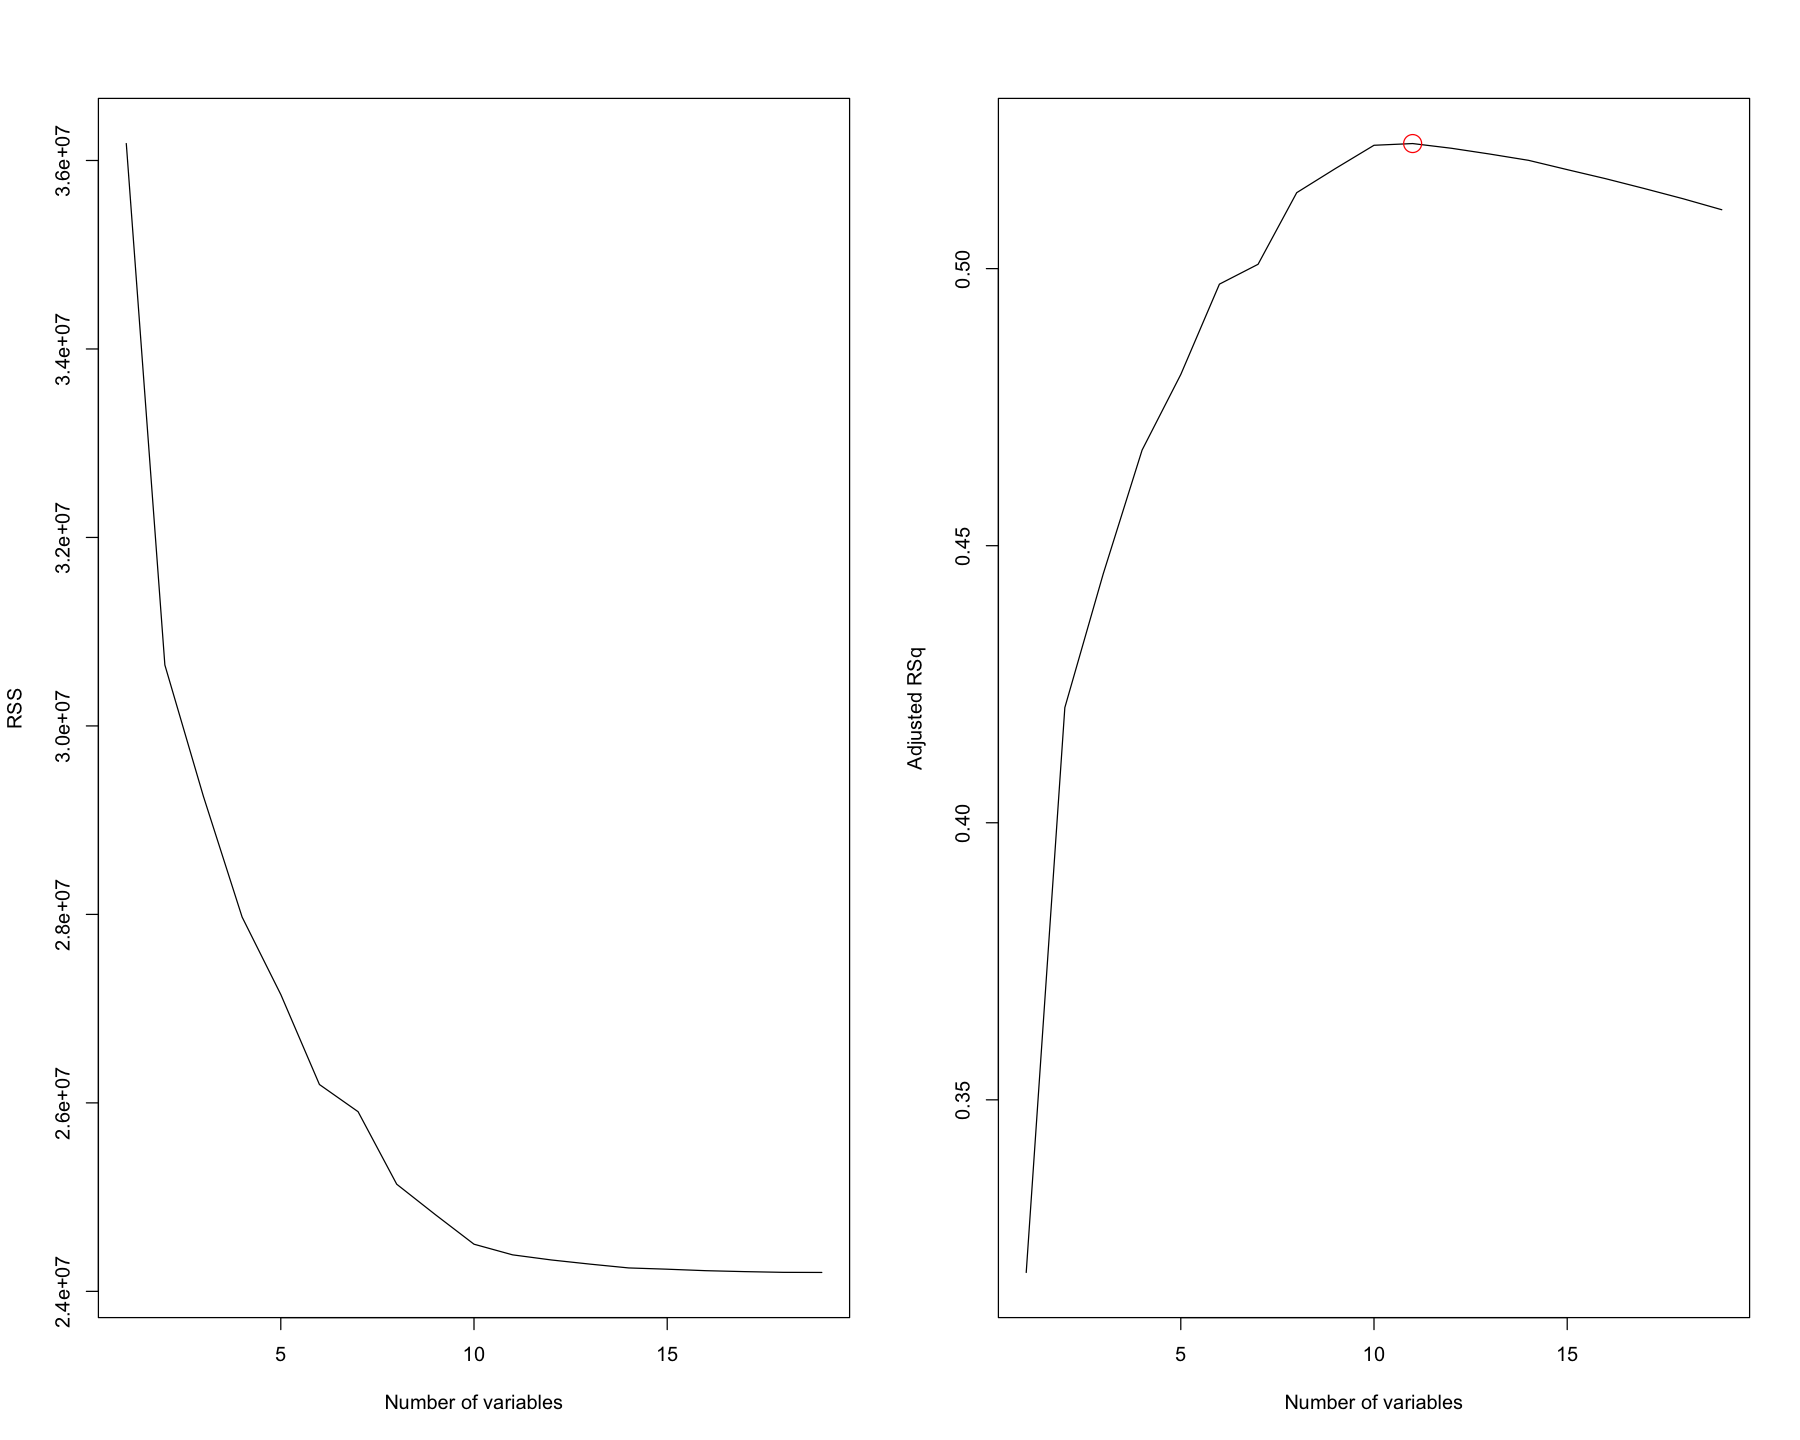

In [19]:
par(mfrow=c(1,2))
plot(reg.summary$rss, xlab="Number of variables", ylab="RSS", type="l")
plot(reg.summary$adjr2, xlab="Number of variables", ylab="Adjusted RSq", type="l")
points(11, reg.summary$adjr2[11], col="red", cex=2)

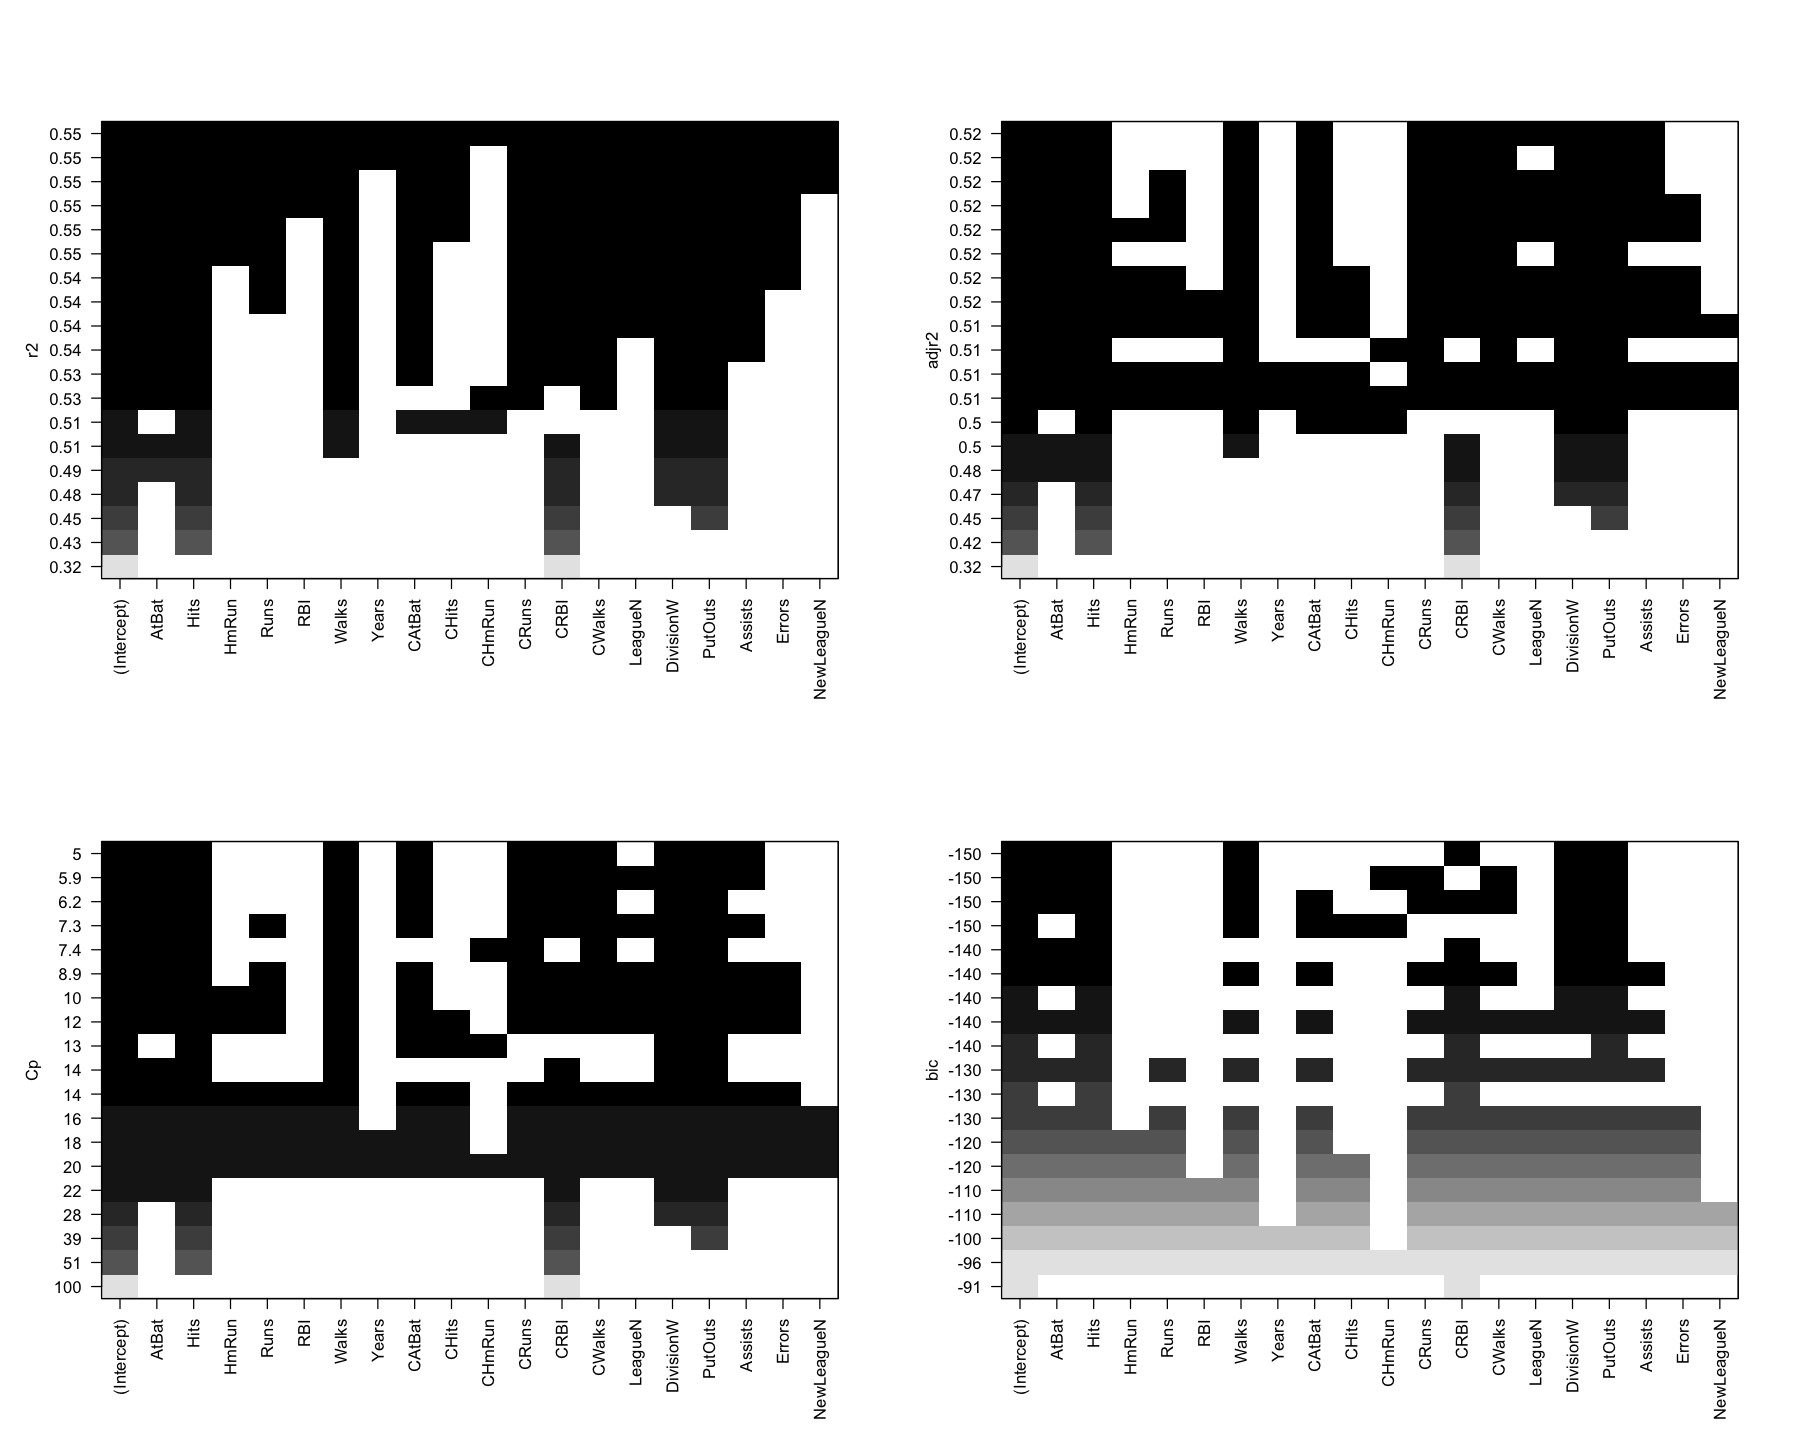

In [20]:
par(mfrow=c(2,2))
plot(regfit.full, scale="r2")
plot(regfit.full, scale="adjr2")
plot(regfit.full, scale="Cp")
plot(regfit.full, scale="bic")

In [21]:
coef(regfit.full,6)

(Intercept)        AtBat         Hits        Walks         CRBI    DivisionW 
  91.5117981   -1.8685892    7.6043976    3.6976468    0.6430169 -122.9515338 
     PutOuts 
   0.2643076

In [22]:
names(Hitters)

[1] "AtBat"     "Hits"      "HmRun"     "Runs"      "RBI"       "Walks"    
 [7] "Years"     "CAtBat"    "CHits"     "CHmRun"    "CRuns"     "CRBI"     
[13] "CWalks"    "League"    "Division"  "PutOuts"   "Assists"   "Errors"   
[19] "Salary"    "NewLeague"

In [23]:
set.seed(1)

In [24]:
library(glmnet)

In [25]:
x = model.matrix(Salary ~ ., Hitters)[,-1]

In [26]:
y = Hitters$Salary

In [27]:
grid = 10^seq(10, -2, length=100)

In [28]:
ridge.mod = glmnet(x, y, alpha=0, lmbda=grid)

In [29]:
dim(coef(ridge.mod))

[1]  20 100

In [30]:
ridge.mod$lambda[50]

[1] 2674.375

In [31]:
ridge.mod$lambda[30]

[1] 17191.08

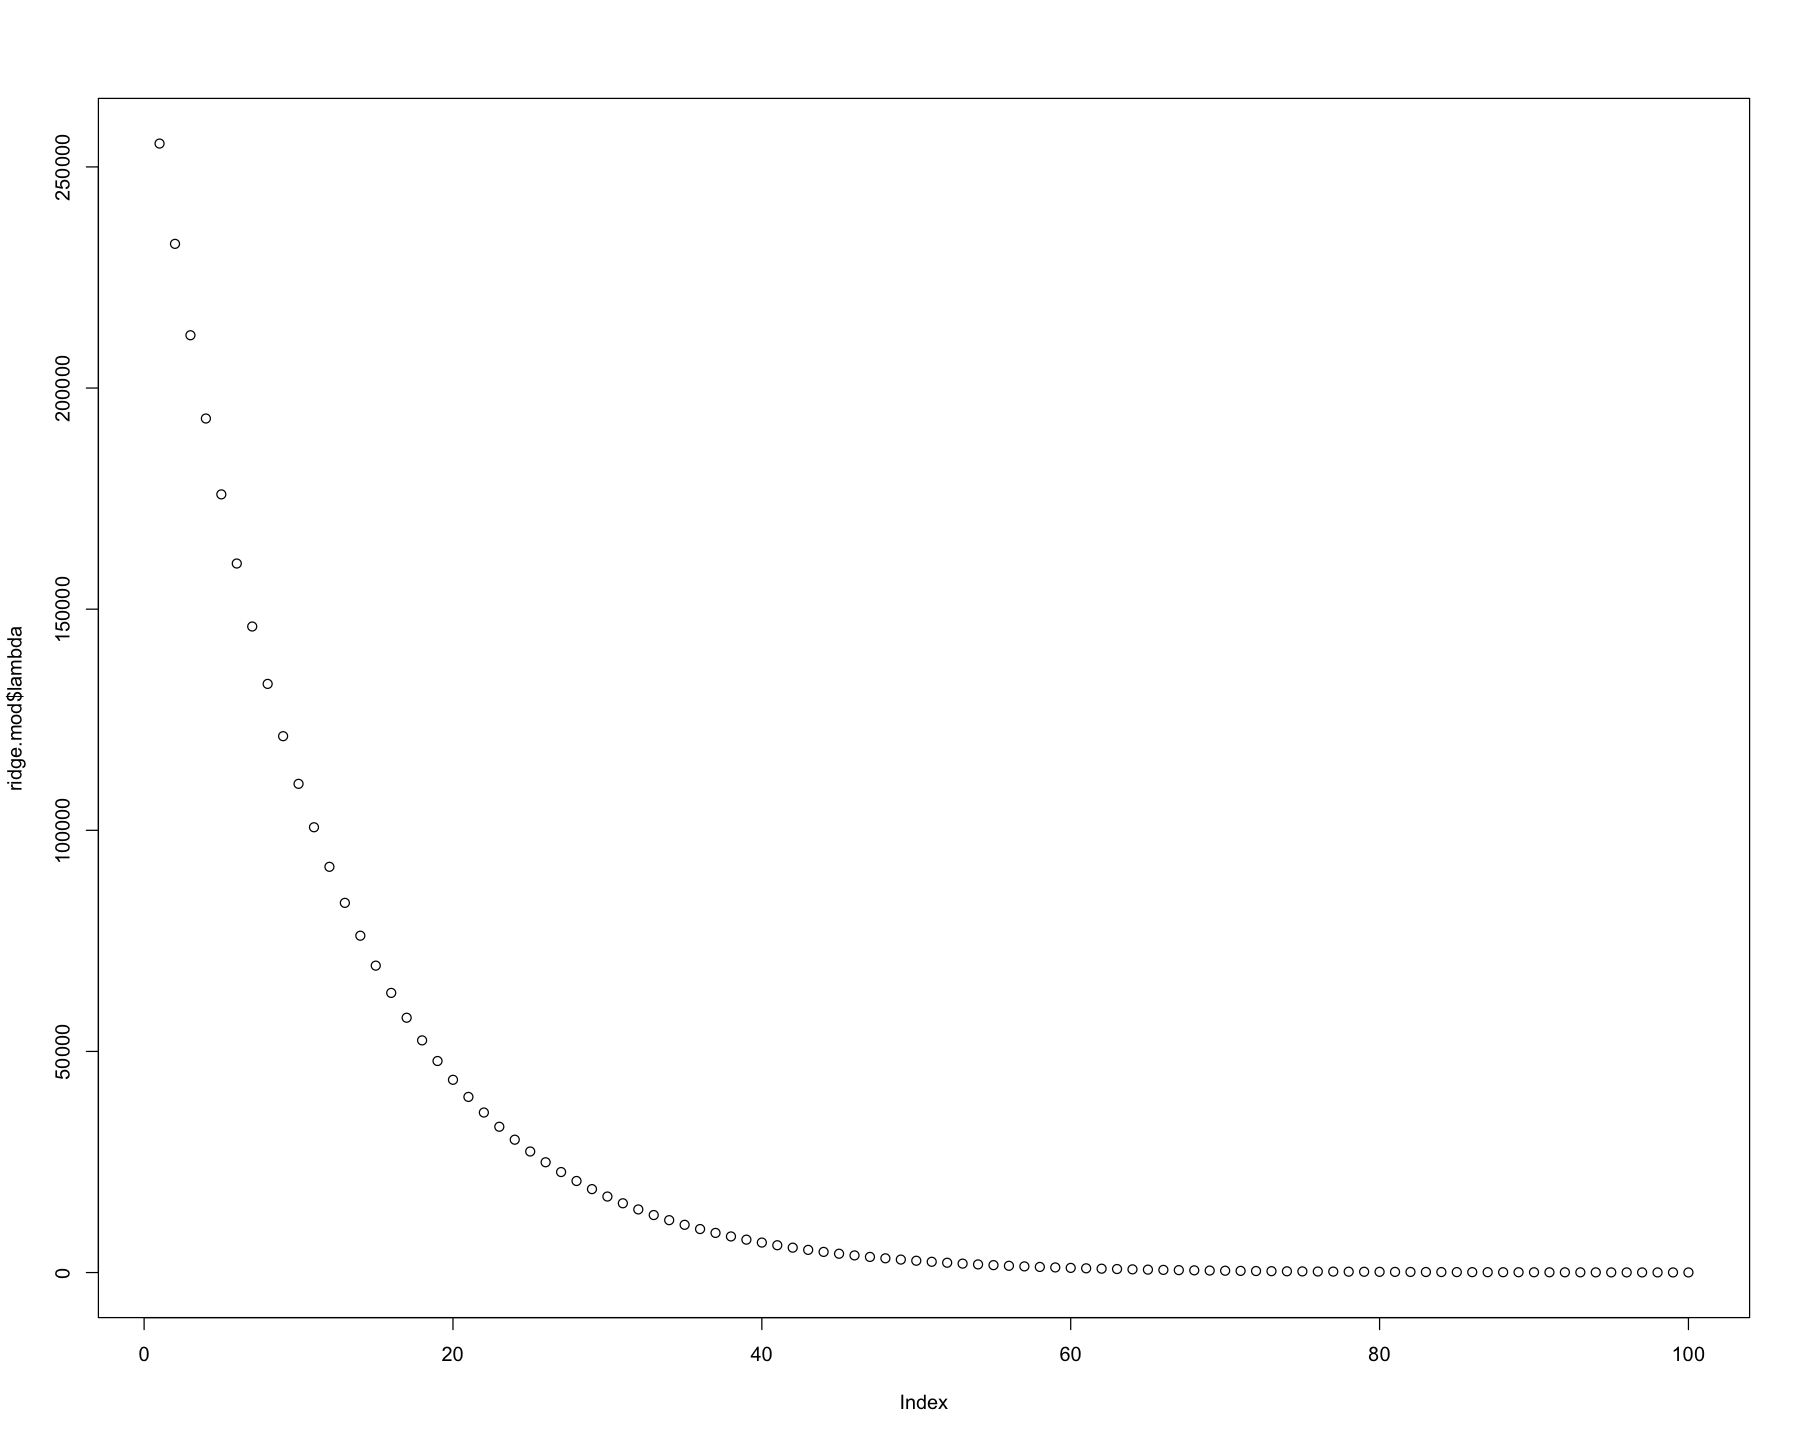

In [32]:
plot(ridge.mod$lambda)

In [33]:
coef(ridge.mod)[,20]

(Intercept)         AtBat          Hits         HmRun          Runs 
 4.955925e+02  1.163271e-02  4.253756e-02  1.686669e-01  7.168666e-02 
          RBI         Walks         Years        CAtBat         CHits 
 7.538906e-02  8.934739e-02  3.586635e-01  9.944705e-04  3.670681e-03 
       CHmRun         CRuns          CRBI        CWalks       LeagueN 
 2.765375e-02  7.364295e-03  7.600879e-03  7.998010e-03 -8.224030e-02 
    DivisionW       PutOuts       Assists        Errors    NewLeagueN 
-1.745848e+00  4.801315e-03  7.791613e-04 -4.248398e-03  8.885759e-03

In [34]:
predict(ridge.mod, s=50, typ="coefficients")[1:20,]

(Intercept)         AtBat          Hits         HmRun          Runs 
 4.821654e+01 -3.538650e-01  1.953167e+00 -1.285127e+00  1.156329e+00 
          RBI         Walks         Years        CAtBat         CHits 
 8.087771e-01  2.709765e+00 -6.202919e+00  6.085854e-03  1.070832e-01 
       CHmRun         CRuns          CRBI        CWalks       LeagueN 
 6.290984e-01  2.172926e-01  2.152888e-01 -1.488961e-01  4.586262e+01 
    DivisionW       PutOuts       Assists        Errors    NewLeagueN 
-1.182304e+02  2.501647e-01  1.208491e-01 -3.277073e+00 -9.423459e+00

In [35]:
set.seed(1)
train = sample(1:nrow(x), nrow(x)/2)
test = (-train)
y.test = y[test]

In [36]:
ridge.mod = glmnet(x[train,], y[train], alpha=0,
                   lambda=grid, thresh=1e-12)

In [37]:
ridge.pred = predict(ridge.mod, s=4, newx=x[test,])

In [38]:
mean((ridge.pred - y.test)^2)

[1] 142199.2

In [39]:
ridge.pred = predict(ridge.mod, s=0, newx=x[test,],
                     exact=T, x=x[train,], y=y[train])

In [40]:
mean((ridge.pred -y.test)^2)

[1] 168588.6

In [41]:
lm01 = lm(y ~ x, subset=train)

In [42]:
summary(lm01)


Call:
lm(formula = y ~ x, subset = train)

Residuals:
    Min      1Q  Median      3Q     Max 
-755.40 -172.21  -16.12  148.81 1709.58 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)   
(Intercept)  274.0145   125.3304   2.186   0.0309 * 
xAtBat        -0.3521     0.9547  -0.369   0.7130   
xHits         -1.6377     3.7435  -0.437   0.6626   
xHmRun         5.8145     9.5466   0.609   0.5437   
xRuns          1.5424     4.5241   0.341   0.7338   
xRBI           1.1243     3.8265   0.294   0.7694   
xWalks         3.7287     2.6005   1.434   0.1544   
xYears       -16.3773    17.4006  -0.941   0.3487   
xCAtBat       -0.6412     0.2499  -2.565   0.0116 * 
xCHits         3.1632     1.1572   2.733   0.0073 **
xCHmRun        3.4008     2.9882   1.138   0.2575   
xCRuns        -0.9739     1.1832  -0.823   0.4122   
xCRBI         -0.6005     1.1839  -0.507   0.6130   
xCWalks        0.3379     0.5657   0.597   0.5515   
xLeagueN     119.1486   117.7810   1.012   0.3139   


In [43]:
ridge.pred = predict(ridge.mod, s=0, exact=T, 
    type="coefficients", x=x[train,], y=y[train])

In [44]:
summary(ridge.pred)

i,j,x
<int>,<int>,<dbl>
1,1,274.0200994
2,1,-0.3521900
3,1,-1.6371383
4,1,5.8146692
5,1,1.5423361
6,1,1.1241837
7,1,3.7288406
8,1,-16.3795195
9,1,-0.6411235


In [45]:
set.seed(1)

In [46]:
cv.out <- cv.glmnet(x[train, ], y[train], alpha = 0)

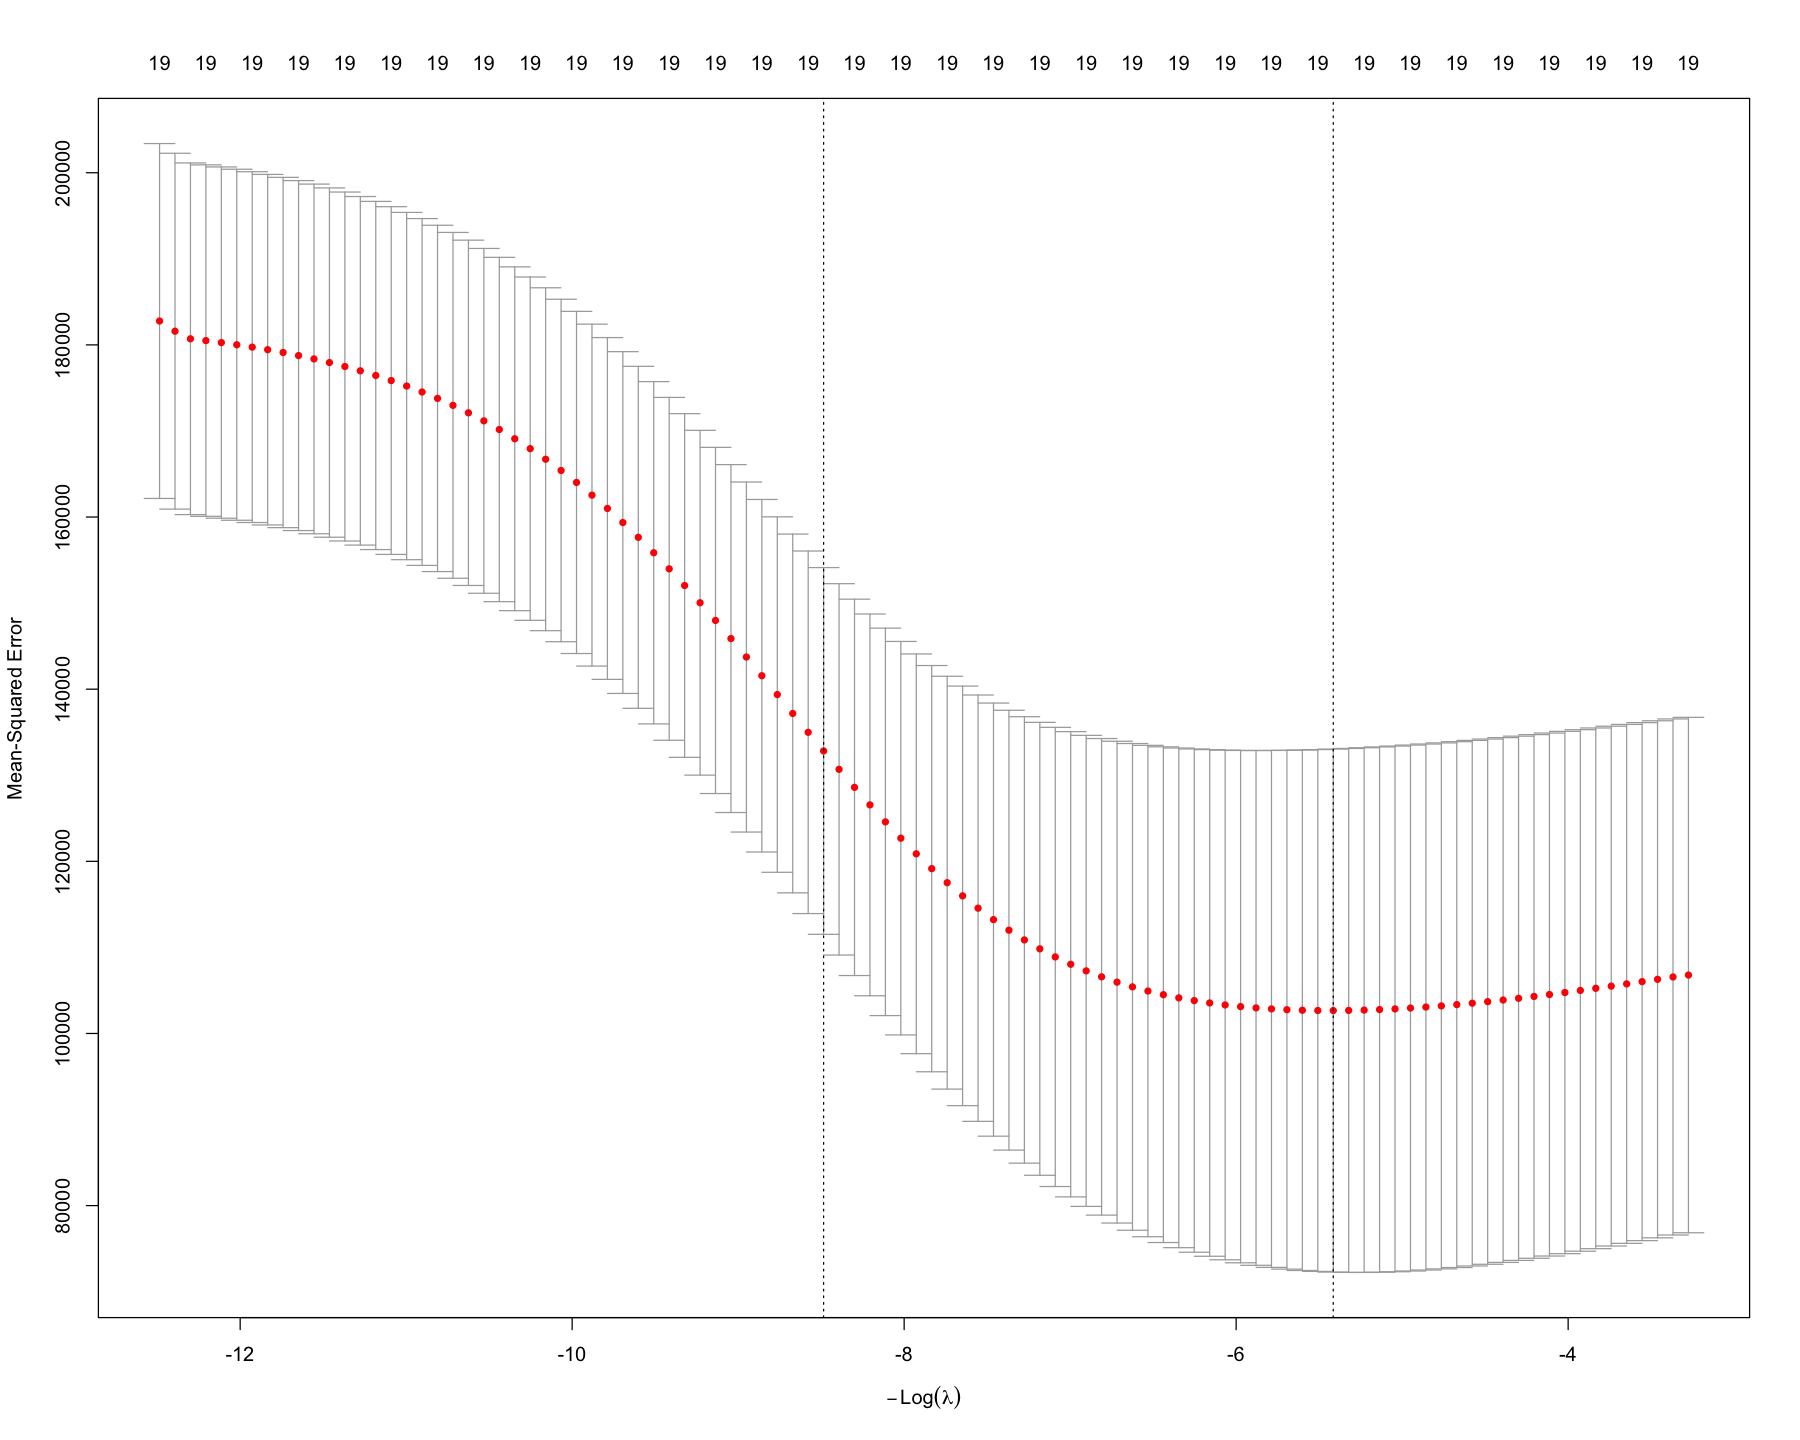

In [47]:
plot(cv.out)

In [48]:
bestlam <- cv.out$lambda.min

In [49]:
bestlam

[1] 224.7562